# Baseline RAG

## Предварительные требования

1. Запустите Qdrant:
    ```
    cd research/rag_experiments
    docker compose up -d
    ```

2. Проиндексируйте документы (один раз):
    ```
    python -m scripts.index_documents
    ```

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from qdrant_client import QdrantClient

from src.config import get_cfg
from src.generator import Generator
from src.retriever import Retriever

cfg = get_cfg()
QDRANT_HOST = str(OmegaConf.select(cfg, "qdrant.host", default="localhost"))
QDRANT_PORT = int(OmegaConf.select(cfg, "qdrant.port", default=6333))
COLLECTION_NAME = str(OmegaConf.select(cfg, "qdrant.collection_name", default="boardgame_rules_chunk512"))

## Информация о проиндексированных данных

In [2]:
client = QdrantClient(host=QDRANT_HOST, port=QDRANT_PORT)
collection_info = client.get_collection(COLLECTION_NAME)

print(f"Collection: {COLLECTION_NAME}")
print(f"Total vectors: {collection_info.points_count}")
print(f"Vector dimension: {collection_info.config.params.vectors.size}")
print(f"Distance metric: {collection_info.config.params.vectors.distance}")

Collection: boardgame_rules_chunk512
Total vectors: 63794
Vector dimension: 768
Distance metric: Cosine


## Тестирование ретривера

In [3]:
retriever = Retriever(cfg)

Using device: mps



🔍 Запрос: Цель игры spyfall


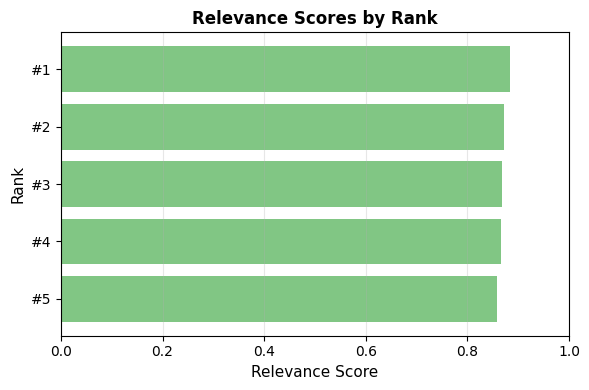


🟢 [1] spyfall. звёздные войны
   Score: 0.885 | Lang: ru | Длина: 949 символов
   ────────────────────────────────────────────────────────────────────
   Обзор игры Игровая партия состоит из последовательности коротких раундов. В каждом раунде игроки оказываются в какой-то локации. Один из участников — шпион Альянса повстанцев, который разыскивает планы «Звезды Смерти». Он не знает, где оказался, поэтому его задача — разговорить других игроков и определить локацию. Но самое главное — не дать разоблачить себя. Тем временем игроки, которые не являютс...

🟢 [2] spyfall. звёздные войны
   Score: 0.872 | Lang: ru | Длина: 748 символов
   ────────────────────────────────────────────────────────────────────
   Задачи и стратегии игроков Задача нешпионов — не только вычислить шпиона, но и постараться не выдать локацию. Поэтому, задавая вопросы, им лучше избегать совсем уж конкретных формулировок («Кого там вчера скормили ранкору?» — спросил один игрок другого, и сидевший по соседству шпион ту

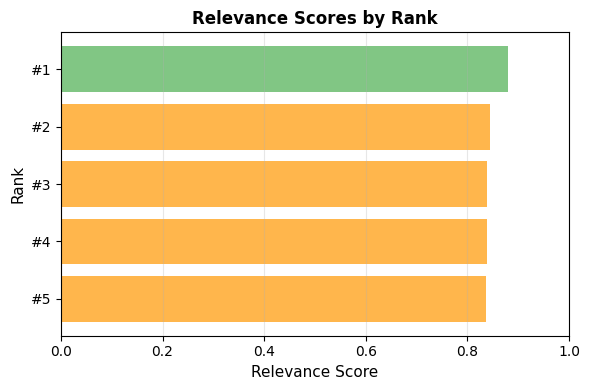


🟢 [1] крагморта
   Score: 0.880 | Lang: ru | Длина: 365 символов
   ────────────────────────────────────────────────────────────────────
   завершается.  КОНЕЦ ИГРЫ  Игра завершается, когда либо игрок получает четвёртую карту Испепеляющего Взора, либо в колоде Книг Магии не остаётся карт. Побеждает игрок с наименьшим числом карт Испепеляющего Взора. При ничьей побеждает претендент на победу с наибольшим числом Книг Магии. Если и теперь ничья, побеждает тот из  спорщиков, у кого больше символов магии.

🟡 [2] кроманьонцы
   Score: 0.844 | Lang: ru | Длина: 915 символов
   ────────────────────────────────────────────────────────────────────
   Конец игры и подсчёт победных очков Окончание игры наступает при достижении одним из игроков определённого числа победных очков, которое зависит от количества игроков: 30 очков 24 очка 22 очка Количество игроков Количество ПО 2 игрока 3 игрока 4 игрока Когда один из игроков достигает установленного количества победных очков, он сразу завершает свой

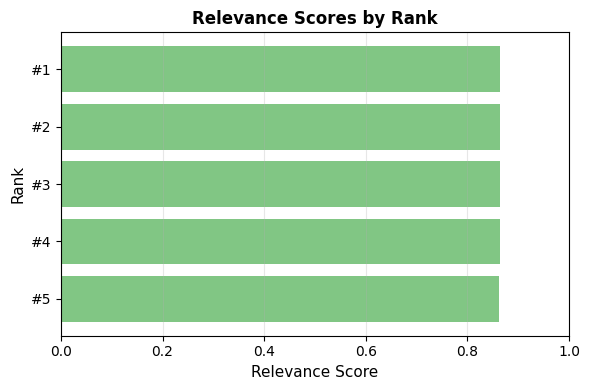


🟢 [1] дюжина короля
   Score: 0.865 | Lang: ru | Длина: 988 символов
   ────────────────────────────────────────────────────────────────────
   48 карт (12 карт для каждого игрока с вензелями разных цветов на обороте карт)  4 карты-памятки  НАБОР КАРТ ДЛЯ ПЕРВОЙ ПАРТИИ  ИСПОЛЬЗУЙТЕ РАЗНЫЕ НАБОРЫ КАРТ В КАЖДОЙ ИГРЕ!  Один из игроков берёт все 12 карт своих союзников. Откладывает карту РЫЦАРЬ, эта карта всегда должна присутствоватьв наборе. Затем перемешивает оставшиеся 11 карт ибизних добавляет к карте РЫЦАРЬ. Среди них должны быть хотя бы...

🟢 [2] таймлайн. изобретения
   Score: 0.865 | Lang: ru | Длина: 815 символов
   ────────────────────────────────────────────────────────────────────
   В начале игры первый игрок должен положить карту справа или слева от начальной карты. Ход игры Начальная карта Колода карт Карты, розданные игрокам Игрок 1 Игровое пространство Если игрок считает, что его событие произошло раньше события начальной карты, он кладёт свою карту слева от неё. Если игр

In [4]:
test_queries = [
    "Цель игры spyfall",
    "Кто побеждает в конце игры крагморта",
    "Сколько карт раздается в начале игры?",
]


def display_query_results(query, top_k=5):
    results = retriever.retrieve(query, top_k=top_k)
    
    print("\n" + "=" * 70)
    print(f"🔍 Запрос: {query}")
    print("=" * 70)

    if results:
        _, ax1 = plt.subplots(figsize=(6, 4))
        
        scores = [r.score for r in results]
        ranks = list(range(1, len(results) + 1))

        colors = ['#4CAF50' if s > 0.85 else '#FF9800' if s > 0.75 else '#F44336' for s in scores]
        ax1.barh(ranks, scores, color=colors, alpha=0.7)
        ax1.set_xlabel('Relevance Score', fontsize=11)
        ax1.set_ylabel('Rank', fontsize=11)
        ax1.set_title('Relevance Scores by Rank', fontsize=12, fontweight='bold')
        ax1.set_yticks(ranks)
        ax1.set_yticklabels([f"#{r}" for r in ranks])
        ax1.invert_yaxis()
        ax1.grid(axis='x', alpha=0.3)
        ax1.set_xlim(0, 1)
        
        plt.tight_layout()
        plt.show()

    for i, r in enumerate(results, 1):
        games = ", ".join(r.game_titles) if r.game_titles else "Unknown"
        text_preview = r.text[:400].replace("\n", " ").strip()
        if len(r.text) > 400:
            text_preview += "..."

        if r.score > 0.85:
            indicator = "🟢"
        elif r.score > 0.75:
            indicator = "🟡"
        else:
            indicator = "🔴"
        
        print(f"\n{indicator} [{i}] {games}")
        print(f"   Score: {r.score:.3f} | Lang: {r.lang} | Длина: {len(r.text)} символов")
        print(f"   {'─' * 68}")
        print(f"   {text_preview}")
    
    print("\n" + "=" * 70)

    print("\n📊 Сводка:")
    for i, r in enumerate(results, 1):
        games = ", ".join(r.game_titles) if r.game_titles else "Unknown"
        print(f"   {i}. {games[:50]:<50} | {r.score:.3f}")
    
    print()


for query in test_queries:
    display_query_results(query, top_k=5)

### Форматированный контекст для LLM

In [5]:
query = "Цель игры spyfall"
context = retriever.retrieve_with_context(query, top_k=3)

print(f"Запрос: {query}\n")
print("Контекст для LLM:")
print("-" * 70)
print(context)

Запрос: Цель игры spyfall

Контекст для LLM:
----------------------------------------------------------------------
[1] Игра: spyfall. звёздные войны
Релевантность: 0.885
---
Обзор игры Игровая партия состоит из последовательности коротких раундов. В каждом раунде игроки оказываются в какой-то локации. Один из участников
— шпион Альянса повстанцев, который
разыскивает планы «Звезды Смерти». Он не знает, где оказался, поэтому его задача — разговорить других игроков и определить локацию. Но самое главное — не дать разоблачить себя. Тем временем игроки, которые не являются шпионами, пытаются обтекаемо дать понять «своим», что знают, где находятся, и отвести от себя подозрения. Наблюдательность, собранность, выдержка, хитрость — в этой игре пригодится всё. Будьте начеку! Цель игры Цель шпиона повстанцев: не раскрыть себя до окончания раунда или определить локацию, в которой все находятся. Цель остальных игроков: единогласно указать шпиона и, следовательно, разоблачить его. Перед первым рау

### Анализ результатов тестирования ретривера

#### Положительные результаты

**Высокая точность на конкретных запросах**
   - Запрос "Цель игры spyfall": все 4/5 результатов про Spyfall, scores 0.858-0.885
   - Система корректно находит релевантные документы для специфичных запросов

**Хорошая работа с тематическими запросами**
   - Запрос "Кто побеждает в конце игры крагморта": первый результат — Крагморта (0.88), очень высокий score
   - Остальные позиции занимают семантически близкие игры (условия победы, конец игры), что нормально для подобного запроса
   - Система уверенно находит нужную игру на первом месте

**Стабильно высокие scores**
   - Большинство scores > 0.85, что указывает на хорошее качество эмбеддингов
   - Для конкретных запросов с указанием игры scores достигают 0.86–0.88

### Проблемы и ограничения

**Общие запросы дают разнородные результаты**
   - Запрос "Сколько карт раздается в начале игры?": результаты из разных игр, что ожидаемо для общего вопроса без указания конкретной игры
   - Scores для общего запроса высокие (0.862–0.865), эмбеддинги хорошо отражают тематику

## Генерация ответов с помощью LLM

Теперь добавим LLM для генерации ответов на основе найденного контекста.

In [6]:
generator = Generator(cfg)
print(f"LLM Provider: {generator.llm.__class__.__name__}")
print(f"LLM Model: {generator.llm.model if hasattr(generator.llm, 'model') else 'N/A'}")

Using device: mps
LLM Provider: Ollama
LLM Model: qwen2.5:1.5b


### Примеры генерации ответов

In [7]:
test_queries = [
    "Цель игры spyfall",
    "Кто побеждает в конце игры крагморта",
    "Сколько карт раздается в начале игры Таверна Красный Дракон?",
]

for query in test_queries:
    print("=" * 70)
    print(f"🔍 Вопрос: {query}")
    print("=" * 70)

    try:
        answer, context = generator.generate(query, top_k=3)
        print("\n📚 Использованный контекст:")
        print("-" * 70)
        print(context[:500] + "..." if len(context) > 500 else context)
        print("\n💬 Ответ:")
        print("-" * 70)
        print(answer)
    except Exception as e:
        print(f"❌ Ошибка генерации: {e}")
        print("\n💡 Убедитесь, что:")
        print("   - Для Ollama: сервис запущен (ollama serve) и модель загружена")
        print("   - Для OpenAI: установлена переменная окружения OPENAI_API_KEY")
    
    print("\n")

🔍 Вопрос: Цель игры spyfall

📚 Использованный контекст:
----------------------------------------------------------------------
[1] Игра: spyfall. звёздные войны
Релевантность: 0.885
---
Обзор игры Игровая партия состоит из последовательности коротких раундов. В каждом раунде игроки оказываются в какой-то локации. Один из участников
— шпион Альянса повстанцев, который
разыскивает планы «Звезды Смерти». Он не знает, где оказался, поэтому его задача — разговорить других игроков и определить локацию. Но самое главное — не дать разоблачить себя. Тем временем игроки, которые не являются шпионами, пытаются обтекаемо дать понят...

💬 Ответ:
----------------------------------------------------------------------
Цель игры Spyfall — не раскрыть себя до окончания раунда или определить локацию, в которой все находятся.


🔍 Вопрос: Кто побеждает в конце игры крагморта

📚 Использованный контекст:
----------------------------------------------------------------------
[1] Игра: крагморта
Релевантность:

### Сравнение: RAG vs LLM без контекста

Чтобы понять, помогает ли RAG, запустим те же запросы **без** контекста из базы - только LLM по вопросу. Если без контекста модель не знает ответ или выдумывает, а с RAG отвечает по правилам - RAG действительно полезен.

In [8]:
for query in test_queries:
    print("=" * 70)
    print(f"🔍 Вопрос: {query}")
    print("=" * 70)
    
    print("\n📌 С RAG (контекст из базы):")
    print("-" * 70)
    try:
        answer_rag, _ = generator.generate(query, top_k=3)
        print(answer_rag)
    except Exception as e:
        print(f"❌ Ошибка: {e}")
    
    print("\n📌 Без RAG (только LLM, без контекста):")
    print("-" * 70)
    try:
        answer_no_rag = generator.generate_without_context(query)
        print(answer_no_rag)
    except Exception as e:
        print(f"❌ Ошибка: {e}")
    
    print("\n")

🔍 Вопрос: Цель игры spyfall

📌 С RAG (контекст из базы):
----------------------------------------------------------------------
Цель игры Spyfall — не раскрыть себя до окончания раунда или определить локацию, в которой все находятся.

📌 Без RAG (только LLM, без контекста):
----------------------------------------------------------------------
Цель игры "Spyfall" заключается в выживании и уничтожении всех противников, используя свои навыки и информацию для обмана и подозрительности других игроков.


🔍 Вопрос: Кто побеждает в конце игры крагморта

📌 С RAG (контекст из базы):
----------------------------------------------------------------------
Без четвертой карты Испепеляющего Взора или когда колода Книг Магии закончится, победит игрок с наименьшим числом карт Испепеляющего Взора. Если и тогда ничья, побеждает тот из спорщиков, у кого больше символов магии.

📌 Без RAG (только LLM, без контекста):
----------------------------------------------------------------------
В конце игры крагмор

### Анализ результатов работы RAG-пайплайна

#### Положительные результаты

**RAG действительно помогает**
   - С RAG: модель отвечает на основе найденных правил из базы
   - Без RAG: модель выдумывает (например, для Таверна Красный Дракон - «4 карты»)
   - Это подтверждает ценность RAG для доменно-специфичных вопросов

**Качество ответов с RAG**
   - Ответы основаны на реальных правилах из базы данных
   - Для конкретных фактологических вопросов (например, «Сколько карт раздается в начале игры Таверна Красный Дракон?») модель даёт точные краткие ответы («30»)
   - Формулировки краткие и по делу (температура 0 задана для воспроизводимости экспериментов)

**Работа с конкретными запросами**
   - Запросы с указанием игры ("Цель игры spyfall") дают релевантные ответы на основе контекста
   - Система успешно извлекает информацию из релевантных чанков

#### Проблемы и ограничения

**Ограничения модели**
   - Небольшая модель (qwen2.5:1.5b) может иметь ограничения в понимании структурированных правил
   - Модель иногда не извлекает полную информацию из контекста, даже когда она явно присутствует
   - Возможно, требуется более явное структурирование контекста или использование только топ-1 результата для очень конкретных вопросов

**Зависимость от качества ретривера**
   - Ретривер работает отлично (score 0.88 для крагморты); генератор в текущих примерах корректно извлекает основное правило победы
   - Для других запросов может понадобиться приоритизация основной информации над второстепенной

**Общие запросы**
   - Запросы без указания конкретной игры могут давать ответы из разных игр
   - Модель пытается объединить информацию, что может быть некорректно

#### Варианты для улучшения

**Дальнейшее улучшение промптов**
   - Добавить явное указание начинать с основного правила, а затем упоминать исключения
   - Структурировать ответ (например, "Согласно правилам игры X...")
   - Добавить обработку случаев отсутствия информации

**Фильтрация и приоритизация контекста**
   - Для очень конкретных вопросов использовать только топ-1 результат (где основная информация)
   - Добавить порог релевантности (не использовать чанки с score < 0.7)
   - Фильтровать дублирующуюся информацию
   - Приоритизировать чанки из одной игры для конкретных запросов

**Обработка структурированных правил**
   - Если контекст содержит структурированные правила (основное правило + исключения), явно указать модели начинать с основного
   - Использовать более структурированный формат контекста (например, выделять основные правила)

**Использование более мощных моделей**
   - Для более сложных вопросов может потребоваться более мощная модель
   - Текущая модель (qwen2.5:1.5b) хорошо работает для простых фактологических вопросов, но может иметь ограничения для сложных

**Общий вывод:** RAG-пайплайн работает и значительно улучшает качество ответов по сравнению с LLM без контекста. В текущем прогоне: для Spyfall и Крагморты ответы полные и по правилам; для вопроса про число карт в Таверна Красный Дракон модель даёт верный ответ «30» с RAG и ошибочный «4 картs» без RAG. Направления для дальнейшего улучшения: приоритизация основной информации в контексте, порог релевантности для чанков, при необходимости - более мощная модель для сложных правил.